<a href="https://colab.research.google.com/github/auto-d/k8s-taxi/blob/main/eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!wget https://raw.githubusercontent.com/AIPI-561-Operationalizing-AI/Ops-AI-Student/main/week3/data/demand_enriched_corrupted.parquet


--2026-05-27 16:51:30--  https://raw.githubusercontent.com/AIPI-561-Operationalizing-AI/Ops-AI-Student/main/week3/data/demand_enriched_corrupted.parquet
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.110.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 77782772 (74M) [application/octet-stream]
Saving to: ‘demand_enriched_corrupted.parquet.1’

demand_enriched_cor 100%[===================>]  74.18M   237MB/s    in 0.3s    

2026-05-27 16:51:30 (237 MB/s) - ‘demand_enriched_corrupted.parquet.1’ saved [77782772/77782772]



In [2]:
!ls

demand_enriched_corrupted.parquet    sample_data
demand_enriched_corrupted.parquet.1


In [3]:
import pandas as pd

In [4]:
df = pd.read_parquet("demand_enriched_corrupted.parquet")

In [5]:
df.head()

,PULocationID,time_bucket,trip_count,hour,minute,dayofweek,is_weekend,month,dayofyear,weekofyear,...,is_airport_zone,zone_slot_baseline,lag_15min,lag_1h,lag_2h,lag_1day,lag_1week,roll_mean_1h,roll_mean_2h,roll_mean_1day
0,4,2023-01-01 00:00:00,1,0,0,6,1,1,1,52,...,0,7.721212,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,4,2023-01-01 00:15:00,4,0,15,6,1,1,1,52,...,0,8.551515,1.0,NaN,NaN,NaN,NaN,1.0,1.0,1.0
2,4,2023-01-01 00:30:00,4,0,30,6,1,1,1,52,...,0,9.236364,4.0,NaN,NaN,NaN,NaN,2.5,2.5,2.5
3,4,2023-01-01 00:45:00,5,0,45,6,1,1,1,52,...,0,10.581818,4.0,NaN,NaN,NaN,NaN,3.0,3.0,3.0
4,4,2023-01-01 01:00:00,4,1,0,6,1,1,1,52,...,0,11.975758,5.0,1.0,NaN,NaN,NaN,3.5,3.5,3.5


In [6]:
import seaborn as sns

In [7]:
CUTOFF = pd.Timestamp("2026-01-16")

baseline = df[df['time_bucket'] < CUTOFF]   # clean historical window
corrupted = df[df['time_bucket'] >= CUTOFF]  # new potentially corrupted window

print(f"Baseline: {len(baseline)} rows")
print(f"Corrupted: {len(corrupted)} rows")
print(f"\nBaseline columns: {baseline.columns.tolist()}")
print(f"\nBaseline null rates:\n{baseline.isna().mean()}")
print(f"\nCorrupted null rates:\n{corrupted.isna().mean()}")

Baseline: 6079392 rows
Corrupted: 250853 rows

Baseline columns: ['PULocationID', 'time_bucket', 'trip_count', 'hour', 'minute', 'dayofweek', 'is_weekend', 'month', 'dayofyear', 'weekofyear', 'year', 'slot_of_day', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'is_holiday', 'cbd_pricing_active', 'borough_id', 'service_zone_id', 'is_airport_zone', 'zone_slot_baseline', 'lag_15min', 'lag_1h', 'lag_2h', 'lag_1day', 'lag_1week', 'roll_mean_1h', 'roll_mean_2h', 'roll_mean_1day']

Baseline null rates:
PULocationID          0.000000
time_bucket           0.000000
trip_count            0.000000
hour                  0.000000
minute                0.000000
dayofweek             0.000000
is_weekend            0.000000
month                 0.000000
dayofyear             0.000000
weekofyear            0.000000
year                  0.000000
slot_of_day           0.000000
hour_sin              0.000000
hour_cos              0.000000
dow_sin               0.000000
dow_cos 

In [14]:
baseline.columns == corrupted.columns

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True])

In [52]:
from matplotlib import pyplot as plt

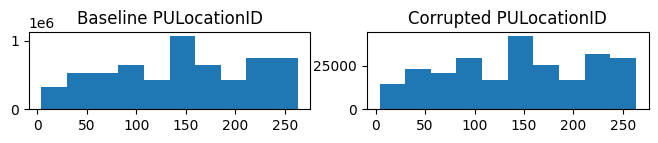

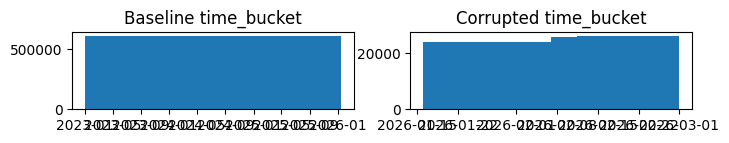

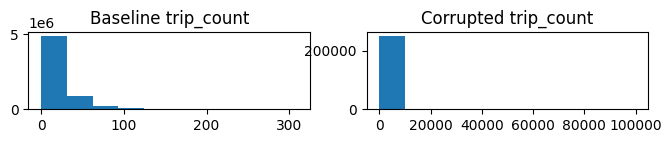

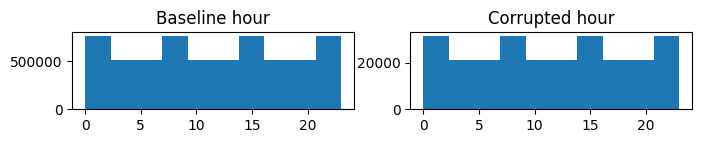

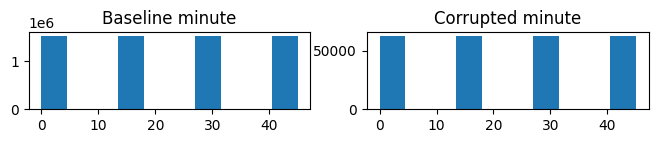

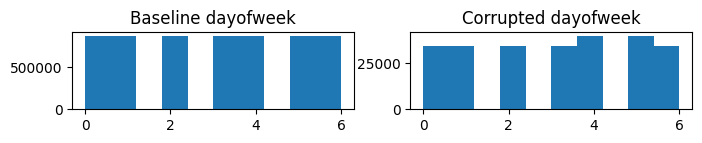

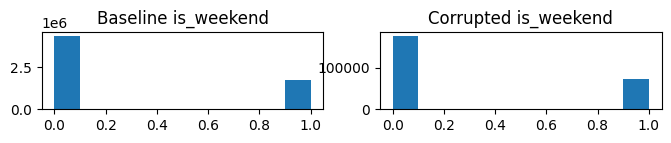

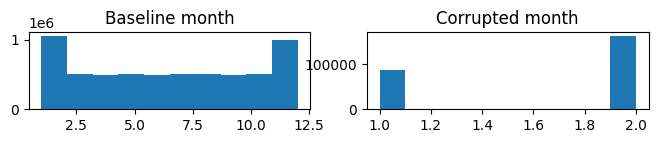

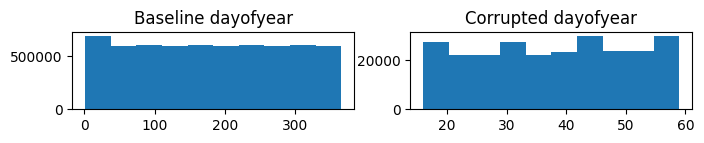

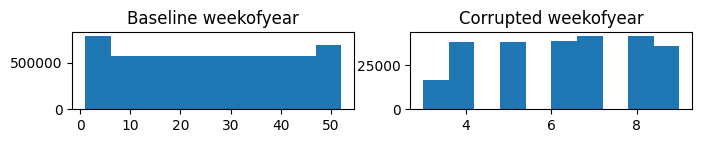

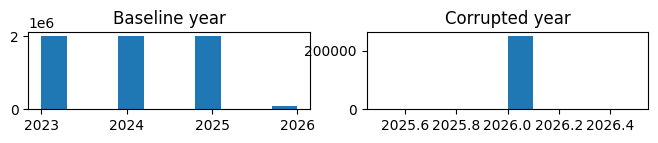

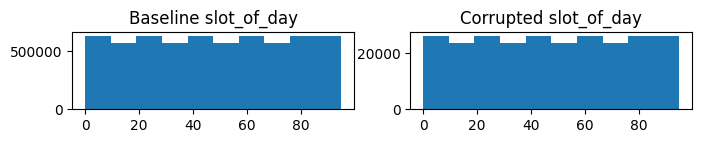

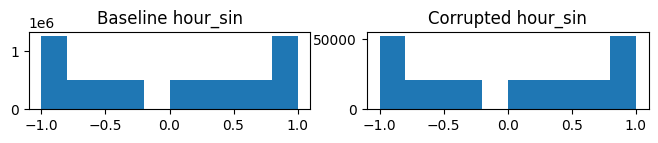

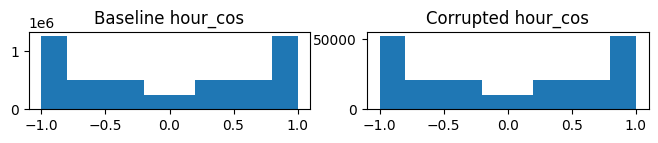

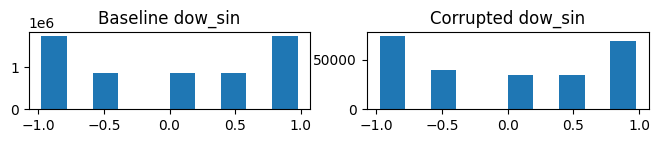

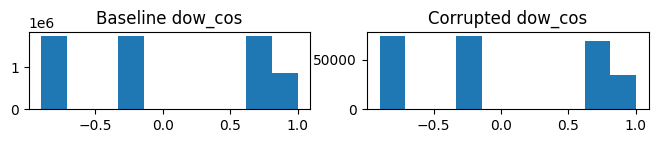

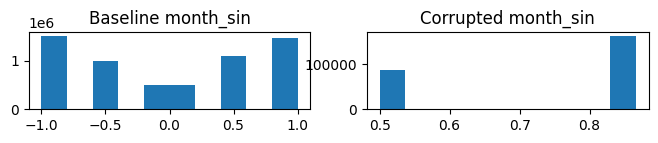

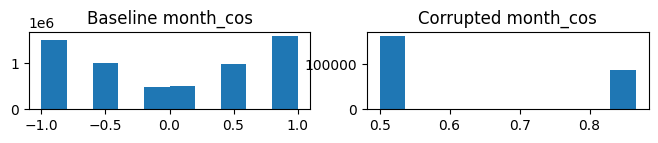

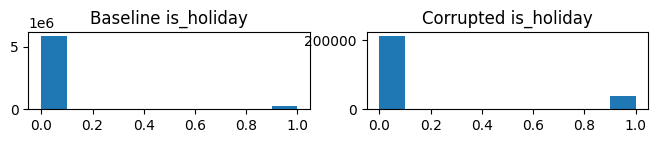

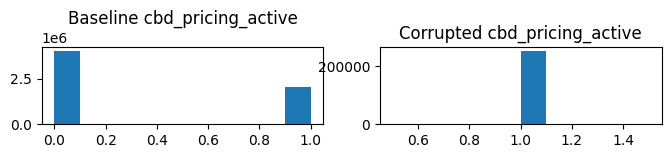

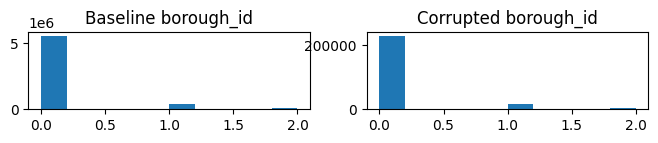

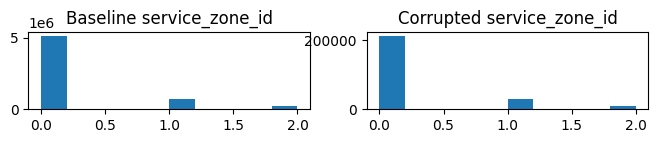

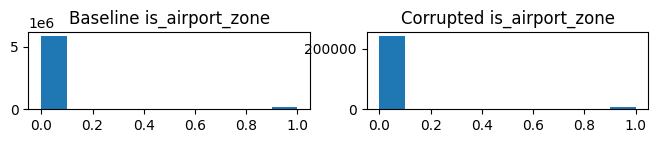

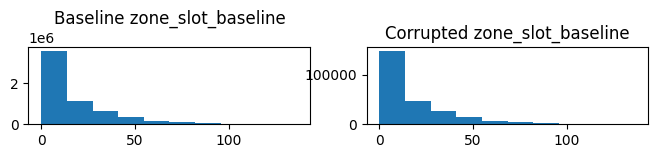

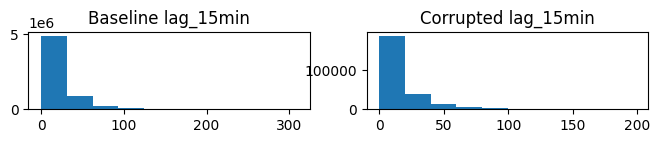

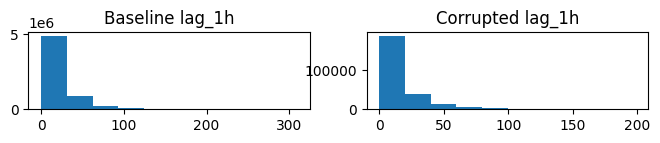

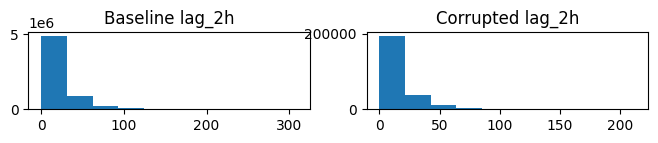

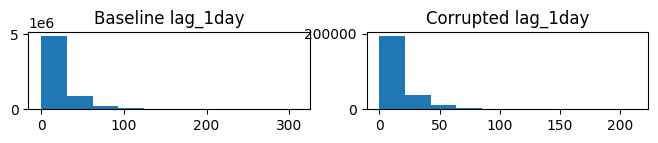

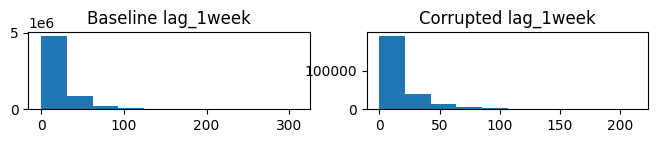

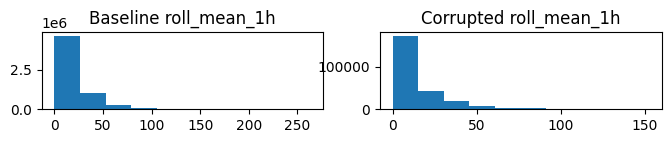

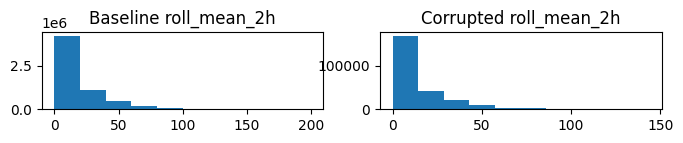

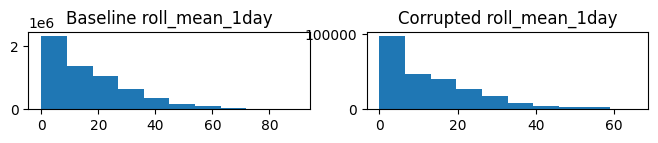

In [61]:
for col in baseline.columns:
  fig, axes = plt.subplots(1, 2, figsize=(8, 1))
  axes[0].hist(baseline[col])
  axes[1].hist(corrupted[col])
  axes[0].set_title(f"Baseline {col}")
  axes[1].set_title(f"Corrupted {col}")
  plt.show()


In [42]:
baseline.isna().value_counts()

PULocationID  time_bucket  trip_count  hour   minute  dayofweek  is_weekend  month  dayofyear  weekofyear  year   slot_of_day  hour_sin  hour_cos  dow_sin  dow_cos  month_sin  month_cos  is_holiday  cbd_pricing_active  borough_id  service_zone_id  is_airport_zone  zone_slot_baseline  lag_15min  lag_1h  lag_2h  lag_1day  lag_1week  roll_mean_1h  roll_mean_2h  roll_mean_1day
False         False        False       False  False   False      False       False  False      False       False  False        False     False     False    False    False      False      False       False               False       False            False            False               False      False   False   False     False      False         False         False             6041088
                                                                                                                                                                                                                                                                                                                                  True       False         False         False               32832
                                                                                                                                                                                                                                                                                                                        True      True       False         False         False                5016
                                                                                                                                                                                                                                                                                                                True    True      True       False         False         False                 228
                                                                                                                                                                                                                                                                                                        True    True    True      True       False         False         False                 171
                                                                                                                                                                                                                                                                                             True       True    True    True      True       True          True          True                   57
Name: count, dtype: int64

In [43]:
corrupted.isna().value_counts()

,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,count
PULocationID,time_bucket,trip_count,hour,minute,dayofweek,is_weekend,month,dayofyear,weekofyear,year,slot_of_day,hour_sin,hour_cos,dow_sin,dow_cos,month_sin,month_cos,is_holiday,cbd_pricing_active,borough_id,service_zone_id,is_airport_zone,zone_slot_baseline,lag_15min,lag_1h,lag_2h,lag_1day,lag_1week,roll_mean_1h,roll_mean_2h,roll_mean_1day,
False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,250853


In [47]:
baseline.describe()

,PULocationID,time_bucket,trip_count,hour,minute,dayofweek,is_weekend,month,dayofyear,weekofyear,...,is_airport_zone,zone_slot_baseline,lag_15min,lag_1h,lag_2h,lag_1day,lag_1week,roll_mean_1h,roll_mean_2h,roll_mean_1day
count,6.079392e+06,6079392,6.079392e+06,6.079392e+06,6.079392e+06,6.079392e+06,6.079392e+06,6.079392e+06,6.079392e+06,6.079392e+06,...,6.079392e+06,6.079392e+06,6.079335e+06,6.079164e+06,6.078936e+06,6.073920e+06,6.041088e+06,6.079335e+06,6.079335e+06,6.079335e+06
mean,1.456140e+02,2024-07-09 11:52:29.999988736,1.703395e+01,1.150000e+01,2.250000e+01,2.997300e+00,2.853285e-01,6.447345e+00,1.808020e+02,2.612331e+01,...,3.508772e-02,1.690868e+01,1.703400e+01,1.703409e+01,1.703386e+01,1.703355e+01,1.790484e+01,1.703403e+01,1.703404e+01,1.703022e+01
min,4.000000e+00,2023-01-01 00:00:00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,8.800000e+01,2023-10-05 17:56:15,2.000000e+00,5.750000e+00,1.125000e+01,1.000000e+00,0.000000e+00,3.000000e+00,8.800000e+01,1.300000e+01,...,0.000000e+00,2.187879e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.250000e+00,5.208333e+00
50%,1.430000e+02,2024-07-09 11:52:30,9.000000e+00,1.150000e+01,2.250000e+01,3.000000e+00,0.000000e+00,6.000000e+00,1.810000e+02,2.600000e+01,...,0.000000e+00,8.896970e+00,9.000000e+00,9.000000e+00,9.000000e+00,9.000000e+00,9.000000e+00,8.750000e+00,8.875000e+00,1.380208e+01
75%,2.110000e+02,2025-04-13 05:48:45,2.500000e+01,1.725000e+01,3.375000e+01,5.000000e+00,1.000000e+00,9.000000e+00,2.730000e+02,3.900000e+01,...,0.000000e+00,2.521212e+01,2.500000e+01,2.500000e+01,2.500000e+01,2.500000e+01,2.600000e+01,2.475000e+01,2.487500e+01,2.508333e+01
max,2.630000e+02,2026-01-15 23:45:00,3.100000e+02,2.300000e+01,4.500000e+01,6.000000e+00,1.000000e+00,1.200000e+01,3.660000e+02,5.200000e+01,...,1.000000e+00,1.367636e+02,3.100000e+02,3.100000e+02,3.100000e+02,3.100000e+02,3.100000e+02,2.635000e+02,1.997500e+02,8.987500e+01
std,7.191169e+01,NaN,2.157228e+01,6.922187e+00,1.677051e+01,2.000673e+00,4.515708e-01,3.484396e+00,1.066825e+02,1.522197e+01,...,1.840016e-01,2.007101e+01,2.151582e+01,2.151598e+01,2.151571e+01,2.151409e+01,2.236411e+01,2.097011e+01,2.066835e+01,1.446796e+01


In [46]:
corrupted.describe()

,PULocationID,time_bucket,trip_count,hour,minute,dayofweek,is_weekend,month,dayofyear,weekofyear,...,is_airport_zone,zone_slot_baseline,lag_15min,lag_1h,lag_2h,lag_1day,lag_1week,roll_mean_1h,roll_mean_2h,roll_mean_1day
count,250853.000000,250853,250853.000000,250853.000000,250853.000000,250853.000000,250853.000000,250853.000000,250853.000000,250853.000000,...,250853.000000,250853.000000,250853.000000,250853.000000,250853.000000,250853.000000,250853.000000,250853.000000,250853.000000,250853.000000
mean,143.539005,2026-02-07 10:57:57.438580224,78.672804,11.500229,22.500448,3.065481,0.295077,1.650983,37.962113,6.270948,...,0.033677,16.741651,13.583325,13.576493,13.574520,13.621842,14.889257,13.579822,13.577316,13.621077
min,4.000000,2026-01-16 00:00:00,-5.000000,0.000000,0.000000,0.000000,0.000000,1.000000,16.000000,3.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,87.000000,2026-01-27 11:00:00,1.000000,6.000000,15.000000,1.000000,0.000000,1.000000,27.000000,5.000000,...,0.000000,2.169697,1.000000,1.000000,1.000000,1.000000,1.000000,1.250000,1.375000,3.375000
50%,142.000000,2026-02-07 22:00:00,6.000000,12.000000,30.000000,3.000000,0.000000,2.000000,38.000000,6.000000,...,0.000000,8.884848,6.000000,6.000000,6.000000,6.000000,7.000000,6.000000,6.000000,10.614583
75%,211.000000,2026-02-18 11:00:00,19.000000,18.000000,45.000000,5.000000,1.000000,2.000000,49.000000,8.000000,...,0.000000,25.084848,19.000000,19.000000,19.000000,19.000000,21.000000,19.500000,19.500000,20.239584
max,263.000000,2026-02-28 23:45:00,99999.000000,23.000000,45.000000,6.000000,1.000000,2.000000,59.000000,9.000000,...,1.000000,136.763636,199.000000,199.000000,213.000000,213.000000,213.000000,152.250000,143.500000,65.541664
std,72.804804,NaN,2433.026184,6.922322,16.770677,1.982495,0.456078,0.476660,12.702045,1.841399,...,0.180397,19.793022,18.628445,18.620142,18.622719,18.754066,20.042439,18.110996,17.836670,12.513944


In [51]:
for i in zip(baseline.dtypes, corrupted.dtypes):
  print(i[0]==i[1], i)

True (dtype('int64'), dtype('int64'))
True (dtype('<M8[ns]'), dtype('<M8[ns]'))
True (dtype('int32'), dtype('int32'))
True (dtype('int32'), dtype('int32'))
True (dtype('int32'), dtype('int32'))
True (dtype('int32'), dtype('int32'))
True (dtype('int8'), dtype('int8'))
True (dtype('int32'), dtype('int32'))
True (dtype('int32'), dtype('int32'))
True (dtype('int64'), dtype('int64'))
True (dtype('int32'), dtype('int32'))
True (dtype('int32'), dtype('int32'))
True (dtype('float64'), dtype('float64'))
True (dtype('float64'), dtype('float64'))
True (dtype('float64'), dtype('float64'))
True (dtype('float64'), dtype('float64'))
True (dtype('float64'), dtype('float64'))
True (dtype('float64'), dtype('float64'))
True (dtype('int8'), dtype('int8'))
True (dtype('int8'), dtype('int8'))
True (dtype('int64'), dtype('int64'))
True (dtype('int64'), dtype('int64'))
True (dtype('int8'), dtype('int8'))
True (dtype('float64'), dtype('float64'))
True (dtype('float32'), dtype('float32'))
True (dtype('float32')